In [1]:
# !/usr/bin/env python
import glob
from subprocess import run

import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from transit_time_dependence_plots import (extract_json, extract_json_tts_filter, extract_json_min_tts_filter, extract_json_tts_chi2_filter,plot_single_transit_time_histogram,
                                           prod_id_to_icm_id,extract_channel,extract_fit_params)

from refit_bad_tt_fits import merge_bins_reduceat
from transit_time_fit_functions import gaussian

import json

from pathlib import Path
home = str(Path.home())

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams.update({'font.size': 10})


# colorsCustom = ['#8dd3c7','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9','#bc80bd','#ccebc5','#ffed6f','#1f78b4','#33a02c','#e31a1c','#a6cee3','#b2df8a','#fb9a99','#fdbf6f','#ff7f00','#cab2d6','#ffff99','#6a3d9a','#b15928','#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e','#e6ab02','#a6761d','#666666','#1f78b4']
colorsCustom = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377", "#BBBBBB", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000075", "#F032E6", "#42D4F4", "#FABED4", "#469990", "#DCBEFF", "#9A6324", "#FFFAC8", "#800000", "#AAFFC3", "#808000", "#FFD8B1", "#911EB4", "#3CB44B", "#E6194B", "#8B8682"]


In [2]:
C_msu = 23.9 #ns
C_desy = 25.5 #ns
upgrade_commissioning_scripts = home+"/research_ua/icecube/software/upgrade_commissioning_scripts/"
geometry_files = sorted(glob.glob(upgrade_commissioning_scripts+"/geometry/string_*geometry*.json"))
mdom_tt_dir = home+"/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/"
plotFolder: str = home+"/research_ua/icecube/Upgrade/timing_calibration/plots/mdom_transit"
run_picks_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mDOM_tt_run_picks_with_MSU_list.json"
refit_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_tt_needing_refit.json"
empty_meas_json = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mDOM_tt_empty_meas.json"

transit_time_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time.json"
transit_times_single_per_pmt_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_single_pick.json"
transit_times_single_gaussian_file = home+"/research_ua/icecube/upgrade/timing_calibration/scripts/mdom_transit_time_gaussian_refit.json"
# transit_times = extract_json(transit_time_file,obj_key="mu",filter_non_zero=False)
# transit_times_single_per_pmt = extract_json_unique_tt(transit_time_file,run_picks_json,refit_json,empty_meas_json,obj_key="mu",filter_non_zero=True)

In [3]:
from plot_transit_time_single_gaussian import (plot_transit_time_histogram
                                               ,plot_transit_time_spread_histogram,
                                               plot_rse_histogram)

In [46]:
def extract_json_site(transit_time_file,site_str,obj_key,filter_non_zero) -> list:
    '''
    Reads the json file with the list of DOMs and transit time measurements and returns a list of transit times
    and other data values
    for chi2, object key : "chi2"
    for transit time, object key:"mu"

    '''
    data_values = []
    tt_less_23 = []
    unique_mDOMs = []    
    with open(transit_time_file, 'r') as f:
        data = json.load(f)
        for mdom, tt_data in data.items():
            if site_str in mdom:
                for ichannel in tt_data["transit_times"]:
                    for itt in tt_data["transit_times"][ichannel]:
                        if len(itt) > 0 and itt["sigma"] > 4:
                        # if len(itt) > 0 and itt["mu"] >36:
                            tt_less_23.append(f"{mdom}_{ichannel}_{itt['run_number']}")
                            unique_mDOMs.append(f"{mdom}")
                        if len(itt) > 0:
                            if filter_non_zero:
                                if abs(itt["mu"]) > 0:
                                    data_values.append(itt[obj_key])
                            else:
                                data_values.append(itt[obj_key])
    # print(tt_less_23)
    return data_values, tt_less_23,list(set(unique_mDOMs))

In [47]:
transit_times_single_per_pmt_msu,tt_less_23_msu,misfit_mdoms_msu = extract_json_site(transit_times_single_gaussian_file,site_str="_M",obj_key="b",filter_non_zero=False)

In [48]:
transit_times_single_per_pmt_desy,tt_less_23_desy,misfit_mdoms_desy = extract_json_site(transit_times_single_gaussian_file,site_str="_D",obj_key="b",filter_non_zero=False)

In [49]:
print(len(misfit_mdoms_msu))

0


In [50]:
print(len(misfit_mdoms_desy))

13


In [51]:
print(len(tt_less_23_desy))

107


In [52]:
mdom_set = []
for imdom_pmt_run in tt_less_23_desy:
    # print(imdom_pmt_run)
    mdom,channel_run = imdom_pmt_run.split("_channel_")
    channel,run = channel_run.split("_")
    mdom_set.append(mdom)
    print(f"mdom {mdom} channel {channel} run {run}")
print(set(mdom_set))

mdom mDOM_D068 channel 11 run 44
mdom mDOM_D068 channel 18 run 44
mdom mDOM_D068 channel 23 run 44
mdom mDOM_D039 channel 1 run 46
mdom mDOM_D039 channel 3 run 46
mdom mDOM_D039 channel 4 run 46
mdom mDOM_D039 channel 5 run 46
mdom mDOM_D039 channel 6 run 46
mdom mDOM_D039 channel 7 run 46
mdom mDOM_D039 channel 8 run 46
mdom mDOM_D039 channel 9 run 46
mdom mDOM_D039 channel 11 run 46
mdom mDOM_D039 channel 12 run 46
mdom mDOM_D039 channel 13 run 46
mdom mDOM_D039 channel 14 run 46
mdom mDOM_D039 channel 15 run 46
mdom mDOM_D039 channel 16 run 46
mdom mDOM_D039 channel 17 run 46
mdom mDOM_D039 channel 18 run 46
mdom mDOM_D039 channel 19 run 46
mdom mDOM_D039 channel 22 run 46
mdom mDOM_D039 channel 23 run 46
mdom mDOM_D029 channel 2 run 48
mdom mDOM_D029 channel 5 run 48
mdom mDOM_D029 channel 9 run 48
mdom mDOM_D029 channel 11 run 48
mdom mDOM_D029 channel 13 run 48
mdom mDOM_D029 channel 15 run 48
mdom mDOM_D029 channel 17 run 48
mdom mDOM_D067 channel 1 run 42
mdom mDOM_D067 channel

In [45]:
mdom_set = []
for imdom_pmt_run in tt_less_23_msu:
    # print(imdom_pmt_run)
    mdom,channel_run = imdom_pmt_run.split("_channel_")
    channel,run = channel_run.split("_")
    mdom_set.append(mdom)
    print(f"mdom {mdom} channel {channel} run {run}")
print(set(mdom_set))

mdom mDOM_M030 channel 3 run 1143
mdom mDOM_M055 channel 1 run 1122
mdom mDOM_M055 channel 2 run 1122
mdom mDOM_M055 channel 3 run 1122
mdom mDOM_M055 channel 5 run 1122
mdom mDOM_M055 channel 7 run 1122
mdom mDOM_M055 channel 10 run 1122
mdom mDOM_M055 channel 12 run 1122
mdom mDOM_M055 channel 16 run 1122
mdom mDOM_M055 channel 18 run 1122
mdom mDOM_M055 channel 20 run 1122
mdom mDOM_M055 channel 21 run 1122
mdom mDOM_M055 channel 23 run 1122
mdom mDOM_M060 channel 1 run 1426
mdom mDOM_M060 channel 2 run 1426
mdom mDOM_M060 channel 3 run 1426
mdom mDOM_M060 channel 4 run 1426
mdom mDOM_M060 channel 5 run 1426
mdom mDOM_M060 channel 7 run 1426
mdom mDOM_M060 channel 9 run 1426
mdom mDOM_M060 channel 10 run 1426
mdom mDOM_M060 channel 11 run 1426
mdom mDOM_M060 channel 12 run 1426
mdom mDOM_M060 channel 14 run 1426
mdom mDOM_M060 channel 15 run 1426
mdom mDOM_M060 channel 16 run 1426
mdom mDOM_M060 channel 18 run 1426
mdom mDOM_M060 channel 20 run 1426
mdom mDOM_M060 channel 21 run 142

In [ ]:
def plot_single_transit_time_run(mDOM_prod_id, channel, mdom_tt_dir, plotFolder,fit_line=False,fit_xlim=[-30,100],include_runs=[]) -> None:
    '''Plots the transit time histogram for a single mDOM and all its channels'''
    meas_files = glob.glob(f"{mdom_tt_dir}/{mDOM_prod_id}*/*.json")
    print(f"meas files {sorted([ifile for ifile in meas_files if "ch_3" in ifile])}")

    available_channels = [extract_channel(ifile) for ifile in meas_files]
    print(f"available channels for {mDOM_prod_id}: {list(set(available_channels))}")
    meas_files = [ifile for ifile in meas_files if int(extract_channel(ifile)) == int(channel)]
    print(f"meas file {meas_files}")
    if len(meas_files) == 0:
        print(f"meas files for {mDOM_prod_id} channel {channel}: {meas_files}")
    if "_M" in mDOM_prod_id:
        correction = C_msu
    elif "_D" in mDOM_prod_id:
        correction = C_desy
    fig = plt.figure(figsize=(8,5))
    gs = gridspec.GridSpec(nrows=1,ncols=1)
    ax = fig.add_subplot(gs[0])
    x_label = ""
    y_label = ""
    for i,ifile in enumerate(meas_files):
        with open(ifile, 'r') as f:
            data = json.load(f)
            transit_times = []
            y_values = data["meas_data"][0]['y_values']
            # print(f"sum of y values {ifile} {sum(y_values)}")
            x_min = data["meas_data"][0]["x_min"]
            x_max = data["meas_data"][0]["x_max"]
            n_bins = data["meas_data"][0]["n_bins"]
            x_values = np.linspace(x_min,x_max,n_bins)
            x_label = data["meas_data"][0]["x_label"]
            y_label = data["meas_data"][0]["y_label"]
            run = data["run_number"]
            if run not in include_runs:
                continue
            # ax.step(x_values,y_values,ls='-',lw = 2.5,c=colorsCustom[i],label=f" tt {mu:.1f}\u00B1{sigma:.1f} ns PMT HV {hv:.1f} V {temperature:.1f} \u00b0C Run {run}",alpha=1)
            tt, tt_spread, a, b, c, chi2, hv = extract_fit_params(ifile)
            print(f"mdom {mDOM_prod_id} channel {channel} Run {run}: tt {tt:.1f} ns, tts {tt_spread:.1f} ns, a {a:.1f}, b {b:.1f}, c {c:.1f}, chi2 {chi2:.1f}, hv {hv:.1f} V")
            # if c < 20:
            poisson_errors = np.sqrt(np.asarray(y_values))
            poisson_errors[poisson_errors == 0] = 1
            y_fit = gaussian(x_values, a,b,c)
            residuals = y_values - y_fit
            RSS = np.sum(residuals**2)
            ax.errorbar(x_values, y_values, yerr=poisson_errors, fmt='o', color=colorsCustom[0], label=f"Run {run}: tt {b:.0f} ns ({b-correction:.0f} ns) tts {tt_spread:.0f} ns chi2 {chi2:.1f}",alpha=1)
            if fit_line:
                x_values = np.linspace(min(x_values),max(x_values),1000)
                ax.plot(x_values, gaussian(x_values,a,b,c),  '-',c=colorsCustom[1],  linewidth=2.5,   label=rf'Gaussian Fit A$_{{{1}}}$:{a:.0f}, $\mu_{{{1}}}$:{b:.0f}, $\sigma_{{{1}}}$:{c:.0f}'+'\n'+f'RSS = {RSS:.0f}, χ² = {chi2:.1f}')                

    ax.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax.text(0.55, 0.95, f"{mDOM_prod_id} channel {channel}", transform=ax.transAxes, ha='left', fontsize=10)
    # ax.text(0.55, 0.95, f"{mDOM_prod_id} channel {channel} {get_pmt_uid(mDOM_prod_id, int(channel), mdom_tt_dir)}", transform=ax.transAxes, ha='left', fontsize=10)
    ax.set_xlabel(f"{x_label}", fontsize=22)
    ax.set_ylabel(f"{y_label}", fontsize=22)
    ax.grid(True,alpha=0.6)
    ax.legend(fontsize=8,ncols=1)
    plot_name = f"{plotFolder}/{mDOM_prod_id}_channel_{channel}"
    # plt.savefig(plot_name+".png",transparent=False,bbox_inches='tight')
    # plt.savefig(plot_name+".pdf",transparent=False,bbox_inches='tight')
    # plt.close()
    plt.show()

mdom mDOM_M049 channel 1 run 853
meas files ['/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_281.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_320.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_418.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_424.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_426.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_427.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_798.json', '/Users/ep

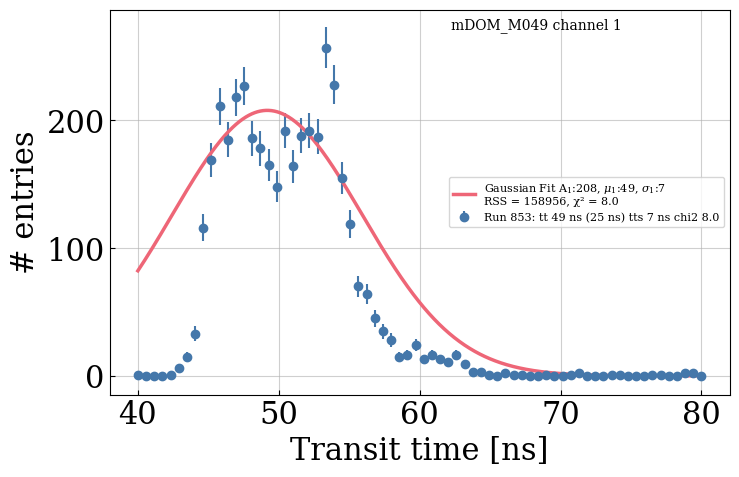

In [ ]:
for imdom_pmt_run in tt_less_23[:1]:
    # print(imdom_pmt_run)
    mdom,channel_run = imdom_pmt_run.split("_channel_")
    channel,run = channel_run.split("_")
    print(f"mdom {mdom} channel {channel} run {run}")
    plot_single_transit_time_run(mdom, int(channel), mdom_tt_dir, plotFolder,fit_line=True,fit_xlim=[-30,100],include_runs=[int(run)])


In [ ]:
def plot_single_transit_time_run_residual(mDOM_prod_id, channel, mdom_tt_dir, plotFolder,fit_line=False,fit_xlim=[-30,100],include_runs=[]) -> None:
    '''Plots the transit time histogram for a single mDOM and all its channels'''
    meas_files = glob.glob(f"{mdom_tt_dir}/{mDOM_prod_id}*/*.json")
    print(f"meas files {sorted([ifile for ifile in meas_files if "ch_3" in ifile])}")

    available_channels = [extract_channel(ifile) for ifile in meas_files]
    print(f"available channels for {mDOM_prod_id}: {list(set(available_channels))}")
    meas_files = [ifile for ifile in meas_files if int(extract_channel(ifile)) == int(channel)]
    print(f"meas file {meas_files}")
    if len(meas_files) == 0:
        print(f"meas files for {mDOM_prod_id} channel {channel}: {meas_files}")
    if "_M" in mDOM_prod_id:
        correction = C_msu
    elif "_D" in mDOM_prod_id:
        correction = C_desy
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                    gridspec_kw={'height_ratios': [3, 1]})
    x_label = ""
    y_label = ""
    for i,ifile in enumerate(meas_files):
        with open(ifile, 'r') as f:
            data = json.load(f)
            transit_times = []
            y_values = data["meas_data"][0]['y_values']
            # print(f"sum of y values {ifile} {sum(y_values)}")
            x_min = data["meas_data"][0]["x_min"]
            x_max = data["meas_data"][0]["x_max"]
            n_bins = data["meas_data"][0]["n_bins"]
            x_values = np.linspace(x_min,x_max,n_bins)
            x_label = data["meas_data"][0]["x_label"]
            y_label = data["meas_data"][0]["y_label"]
            run = data["run_number"]
            if run not in include_runs:
                continue
            # ax.step(x_values,y_values,ls='-',lw = 2.5,c=colorsCustom[i],label=f" tt {mu:.1f}\u00B1{sigma:.1f} ns PMT HV {hv:.1f} V {temperature:.1f} \u00b0C Run {run}",alpha=1)
            tt, tt_spread, a, b, c, chi2, hv = extract_fit_params(ifile)
            print(f"mdom {mDOM_prod_id} channel {channel} Run {run}: tt {tt:.1f} ns, tts {tt_spread:.1f} ns, a {a:.1f}, b {b:.1f}, c {c:.1f}, chi2 {chi2:.1f}, hv {hv:.1f} V")
            # if c < 20:
            poisson_errors = np.sqrt(np.asarray(y_values))
            poisson_errors[poisson_errors == 0] = 1
            y_fit = gaussian(x_values, a,b,c)
            residuals = y_values - y_fit
            RSS = np.sum(residuals**2)
            ax1.errorbar(x_values, y_values, yerr=poisson_errors, fmt='o', color=colorsCustom[0], label=f"Run {run}: tt {b:.0f} ns ({b-correction:.0f} ns) tts {tt_spread:.0f} ns chi2 {chi2:.1f}",alpha=1)
            if fit_line:
                x_values_fit = np.linspace(min(x_values),max(x_values),1000)
                ax1.plot(x_values_fit, gaussian(x_values_fit,a,b,c),  '-',c=colorsCustom[1],  linewidth=2.5,   label=rf'Gaussian Fit A$_{{{1}}}$:{a:.0f}, $\mu_{{{1}}}$:{b:.0f}, $\sigma_{{{1}}}$:{c:.0f}'+'\n'+f'RSS = {RSS:.0f}, χ² = {chi2:.1f}')
                ax2.errorbar(x_values, residuals, yerr=poisson_errors, fmt='o', color=colorsCustom[0], alpha=1)
                ax2.axhline(0, color=colorsCustom[1], linewidth=2)

    ax2.set_ylabel('Residuals', fontsize=22)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both',which='both', direction='in', labelsize=22)                

    ax1.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax1.text(0.55, 0.95, f"{mDOM_prod_id} channel {channel}", transform=ax1.transAxes, ha='left', fontsize=10)
    # ax1.text(0.55, 0.95, f"{mDOM_prod_id} channel {channel} {get_pmt_uid(mDOM_prod_id, int(channel), mdom_tt_dir)}", transform=ax1.transAxes, ha='left', fontsize=10)
    ax2.set_xlabel(f"{x_label}", fontsize=22)
    ax1.set_ylabel(f"{y_label}", fontsize=22)
    ax1.grid(True,alpha=0.6)
    ax1.legend(fontsize=8,ncols=1)
    plot_name = f"{plotFolder}/{mDOM_prod_id}_channel_{channel}"
    # plt.savefig(plot_name+".png",transparent=False,bbox_inches='tight')
    # plt.savefig(plot_name+".pdf",transparent=False,bbox_inches='tight')
    # plt.close()
    plt.show()

mdom mDOM_M049 channel 1 run 853
meas files ['/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_281.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_320.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_418.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_424.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_426.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_427.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_798.json', '/Users/ep

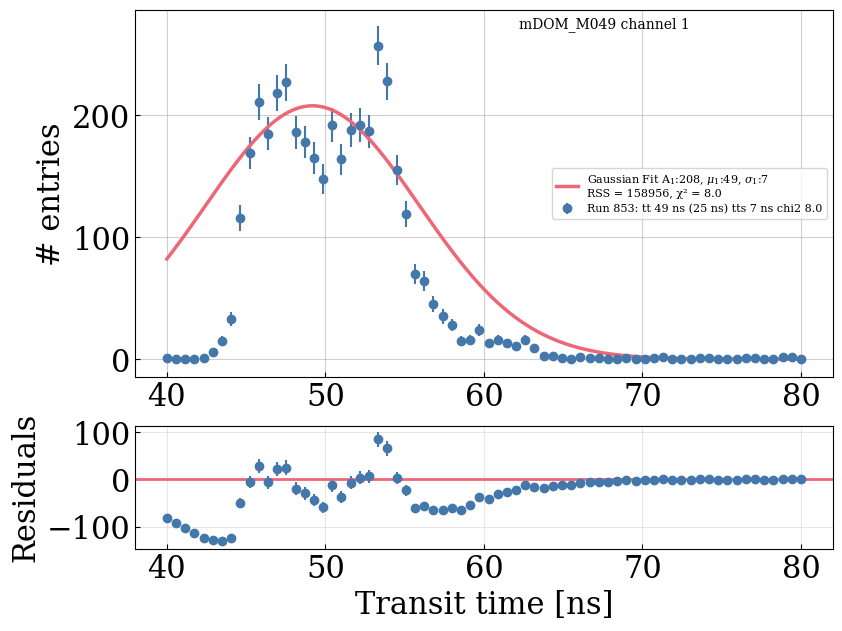

In [ ]:
for imdom_pmt_run in tt_less_23[:1]:
    # print(imdom_pmt_run)
    mdom,channel_run = imdom_pmt_run.split("_channel_")
    channel,run = channel_run.split("_")
    print(f"mdom {mdom} channel {channel} run {run}")
    plot_single_transit_time_run_residual(mdom, int(channel), mdom_tt_dir, plotFolder,fit_line=True,fit_xlim=[-30,100],include_runs=[int(run)])

In [ ]:
def plot_single_gaussian_fit_residual(mDOM_prod_id, channel, mdom_tt_dir, plotFolder,fit_line=False,fit_xlim=[-30,100],include_runs=[]) -> None:
    '''Plots the transit time histogram for a single mDOM and all its channels'''
    meas_files = glob.glob(f"{mdom_tt_dir}/{mDOM_prod_id}*/*.json")
    print(f"meas files {sorted([ifile for ifile in meas_files if "ch_3" in ifile])}")

    available_channels = [extract_channel(ifile) for ifile in meas_files]
    print(f"available channels for {mDOM_prod_id}: {list(set(available_channels))}")
    meas_files = [ifile for ifile in meas_files if int(extract_channel(ifile)) == int(channel)]
    print(f"meas file {meas_files}")
    if len(meas_files) == 0:
        print(f"meas files for {mDOM_prod_id} channel {channel}: {meas_files}")
    if "_M" in mDOM_prod_id:
        correction = C_msu
    elif "_D" in mDOM_prod_id:
        correction = C_desy
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                    gridspec_kw={'height_ratios': [3, 1]})
    x_label = ""
    y_label = ""
    for i,ifile in enumerate(meas_files):
        with open(ifile, 'r') as f:
            data = json.load(f)
            transit_times = []
            y_values = data["meas_data"][0]['y_values']
            # print(f"sum of y values {ifile} {sum(y_values)}")
            x_min = data["meas_data"][0]["x_min"]
            x_max = data["meas_data"][0]["x_max"]
            n_bins = data["meas_data"][0]["n_bins"]
            x_values = np.linspace(x_min,x_max,n_bins)
            x_label = data["meas_data"][0]["x_label"]
            y_label = data["meas_data"][0]["y_label"]
            run = data["run_number"]
            if run not in include_runs:
                continue
            # ax.step(x_values,y_values,ls='-',lw = 2.5,c=colorsCustom[i],label=f" tt {mu:.1f}\u00B1{sigma:.1f} ns PMT HV {hv:.1f} V {temperature:.1f} \u00b0C Run {run}",alpha=1)
            ######################################################################
            initial_guess = [np.max(y_values), 55, 5]
            bounds = ([0, 45, 0.1], #lower limits
                       [np.max(y_values)+100, 65, 5])      # upper limits
            poisson_errors = np.sqrt(np.asarray(y_values))
            poisson_errors[poisson_errors == 0] = 1

            
            popt, pcov = curve_fit(gaussian,x_values,y_values,p0=initial_guess,bounds=bounds,maxfev=10000,sigma=poisson_errors,absolute_sigma=True)

            print(f"popt {popt} {pcov}")



            #####################different initial guess and boundaries###########

            # initial_guess = [np.max(y_values), 55, 3]
            # # bounds = ([0, 30, 0.1,0, 30, 0.1], #lower limits
            # #            [np.max(y_values)+100, 80, 6,np.max(y_values)+100, 80, 6])      # upper limits
            # bounds = ([0.5*np.max(y_values), 45, 0.1], #lower limits
            #             [np.max(y_values)+100, 65, 5])      # upper limits


            # poisson_errors = np.sqrt(np.asarray(y_values))
            # poisson_errors[poisson_errors == 0] = 1

            # popt, pcov = curve_fit(
            #     gaussian,
            #     x_values, y_values,
            #     p0=initial_guess,
            #     bounds=bounds,
            #     maxfev=10000,
            #     sigma=poisson_errors,
            #     absolute_sigma=True
            # )

            perr = np.sqrt(np.diag(pcov))
            perr_dof = perr / np.sqrt(len(x_values) - len(popt))
            chi2 = np.sum(((y_values - gaussian(x_values, *popt))/poisson_errors)**2)
            ndof = len(x_values) - len(popt)
            reduced_chi2 = chi2 / ndof
            a,b,c = popt
            print(a,b,c)

            # -------------------------------------------------------------------
            # Plot
            # -------------------------------------------------------------------
            y_fit = gaussian(x_values, *popt)
            residuals = y_values - y_fit
            RSS = np.sum(residuals**2)
            ax1.errorbar(x_values, y_values, yerr=poisson_errors, fmt='o', color=colorsCustom[0], label=f"Run {run}: tt {b:.0f} ns ({b-correction:.0f} ns) tts {c:.0f} ns chi2 {reduced_chi2:.1f}",alpha=1)
            if fit_line:
                x_values_fit = np.linspace(min(x_values),max(x_values),1000)
                ax1.plot(x_values_fit, gaussian(x_values_fit,*popt),  '-',c=colorsCustom[1],  linewidth=2.5,   label=rf'Gaussian Fit A$_{{{1}}}$:{a:.0f}, $\mu_{{{1}}}$:{b:.0f}, $\sigma_{{{1}}}$:{c:.0f}'+'\n'+f'RSS = {RSS:.0f}, χ² = {reduced_chi2:.1f}')
                ax2.errorbar(x_values, residuals, yerr=poisson_errors, fmt='o', color=colorsCustom[0], alpha=1)
                ax2.axhline(0, color=colorsCustom[1], linewidth=2)

    ax2.set_ylabel('Residuals', fontsize=22)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both',which='both', direction='in', labelsize=22)                

    ax1.tick_params(axis='both',which='both', direction='in', labelsize=22)
    ax1.text(0.55, 0.95, f"{mDOM_prod_id} channel {channel}", transform=ax1.transAxes, ha='left', fontsize=10)
    # ax1.text(0.55, 0.95, f"{mDOM_prod_id} channel {channel} {get_pmt_uid(mDOM_prod_id, int(channel), mdom_tt_dir)}", transform=ax1.transAxes, ha='left', fontsize=10)
    ax2.set_xlabel(f"{x_label}", fontsize=22)
    ax1.set_ylabel(f"{y_label}", fontsize=22)
    ax1.grid(True,alpha=0.6)
    ax1.legend(fontsize=8,ncols=1)
    plot_name = f"{plotFolder}/{mDOM_prod_id}_channel_{channel}"
    # plt.savefig(plot_name+".png",transparent=False,bbox_inches='tight')
    # plt.savefig(plot_name+".pdf",transparent=False,bbox_inches='tight')
    # plt.close()
    plt.show()



mdom mDOM_M049 channel 1 run 853
meas files ['/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_281.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_320.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_418.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_424.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_426.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_427.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M049_v1/mDOM_M049_v1_ch_3_pmt_DM05533_798.json', '/Users/ep

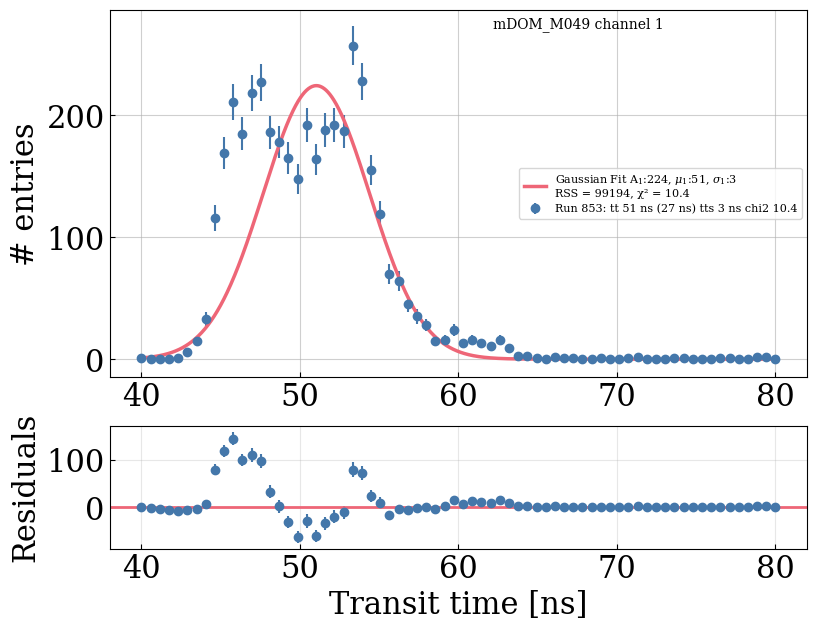

In [ ]:
for imdom_pmt_run in tt_less_23[:1]:
    # print(imdom_pmt_run)
    mdom,channel_run = imdom_pmt_run.split("_channel_")
    channel,run = channel_run.split("_")
    print(f"mdom {mdom} channel {channel} run {run}")
    plot_single_gaussian_fit_residual(mdom, int(channel), mdom_tt_dir, plotFolder,fit_line=True,fit_xlim=[-30,100],include_runs=[int(run)])

In [ ]:
from write_transit_time_single_gaussian_refit import get_single_gaussian_fit

In [ ]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def get_single_gaussian_fit(mDOM_prod_id, channel, mdom_tt_dir) -> None:
    '''Plots the transit time histogram for a single mDOM and all its channels'''
    print(f"Hi")
    meas_files = glob.glob(f"{mdom_tt_dir}/{mDOM_prod_id}*/*.json")
    meas_files = [ifile for ifile in meas_files if extract_channel(ifile) == channel]
    remove_pedestal = None
    merge_bins = None
    A1, mu1, sigma1, reduced_chi2, RSS = np.nan, np.nan, np.nan, np.nan, np.nan
    if mDOM_prod_id in ["mDOM_D092"] and channel == 1:        
        merge_bins = 2
        print(f"{merge_bins} consecutive bins merged for {mDOM_prod_id} channel {channel}")
    if mDOM_prod_id in ["mDOM_D029"] and channel == 1 or mDOM_prod_id in ["mDOM_D034"] and channel == 21:
        remove_pedestal = 0
        print(f"pedestal {remove_pedestal} removed for {mDOM_prod_id} channel {channel}")

    for i,ifile in enumerate(meas_files):
        with open(ifile, 'r') as f:
            data = json.load(f)
            transit_times = []
            y_values = data["meas_data"][0]['y_values']
            x_min = data["meas_data"][0]["x_min"]
            x_max = data["meas_data"][0]["x_max"]
            n_bins = data["meas_data"][0]["n_bins"]
            x_values = np.linspace(x_min,x_max,n_bins)
            x_label = data["meas_data"][0]["x_label"]
            y_label = data["meas_data"][0]["y_label"]
            if remove_pedestal is not None:
                x_values_wo_ped = []
                y_values_wo_ped = []
                for ix,iy in zip(x_values,y_values):
                    if abs(iy - remove_pedestal) > 0.001:
                        x_values_wo_ped.append(ix)
                        y_values_wo_ped.append(iy)

                x_values = x_values_wo_ped
                y_values = y_values_wo_ped
                # print(x_values)
            if merge_bins is not None:
                y_values, x_values = merge_bins_reduceat(y_values, x_values, n=merge_bins)
            initial_guess = [np.max(y_values), 55, 5]
            bounds = ([0, 45, 0.1], #lower limits
                       [np.max(y_values)+100, 65, 5])      # upper limits
            poisson_errors = np.sqrt(np.asarray(y_values))
            poisson_errors[poisson_errors == 0] = 1

            try:
                print(f"{np.mean(y_values)} {np.mean(x_values)}")
                popt, pcov = curve_fit(gaussian,x_values,y_values,p0=initial_guess,bounds=bounds,maxfev=10000,sigma=poisson_errors,absolute_sigma=True)
                print(f"popt {popt} {pcov}")
                A1, mu1, sigma1 = popt
                y_fit = gaussian(x_values, A1, mu1, sigma1)
                residuals = y_values - y_fit
                RSS = np.sum(residuals**2)
                chi2 = np.sum(((y_values - gaussian(x_values, *popt))/poisson_errors)**2)
                ndof = len(x_values) - len(popt)
                reduced_chi2 = chi2 / ndof
                run = data["run_number"]
                # ax.step(x_values,y_values,ls='-',lw = 2.5,c=colorsCustom[i],label=f" tt {mu:.1f}\u00B1{sigma:.1f} ns PMT HV {hv:.1f} V {temperature:.1f} \u00b0C Run {run}",alpha=1)
                tt, tt_spread, a, b, c, chi2, hv = extract_fit_params(ifile)
            except RuntimeError:
                print(f"Gaussian fit did not converge for {mDOM_prod_id} channel {channel}")
                A1, mu1, sigma1, reduced_chi2, RSS = np.nan, np.nan, np.nan, np.nan, np.nan
    # print(f"mdom {mDOM_prod_id} channel {channel}: tt {tt:.1f} ns, tts {tt_spread:.1f} ns, a {a:.1f}, b {b:.1f}, c {c:.1f}, chi2 {chi2:.1f}, hv {hv:.1f} V")
    return A1, mu1, sigma1, reduced_chi2, RSS


In [ ]:
get_single_gaussian_fit('mDOM_M061',3,mdom_tt_dir)

Hi
26.3 60.0
popt [181.15571049  53.92725768   2.05039557] [[ 2.93785516e+01 -3.58025239e-02 -1.02727444e-01]
 [-3.58025239e-02  2.81945130e-03  3.88729698e-04]
 [-1.02727444e-01  3.88729698e-04  1.18838419e-03]]
37.957142857142856 60.0
popt [128.92421027  45.           5.        ] [[ 9.97141592  0.01084356 -0.1873651 ]
 [ 0.01084356  0.03158753 -0.01519555]
 [-0.1873651  -0.01519555  0.01839879]]


(np.float64(128.9242102707607),
 np.float64(45.00000000000177),
 np.float64(4.999999999999999),
 np.float64(4.092817127989038),
 np.float64(20532.55744049211))

mdom mDOM_M061 channel 3 run 789
meas files ['/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M061_v1/mDOM_M061_v1_ch_3_pmt_DM03158_789.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M061_v1/mDOM_M061_v1_ch_3_pmt_DM03158_791.json']
available channels for mDOM_M061: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
meas file ['/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M061_v1/mDOM_M061_v1_ch_3_pmt_DM03158_789.json', '/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/mdom_transit/mDOM_M061_v1/mDOM_M061_v1_ch_3_pmt_DM03158_791.json']
mdom mDOM_M061 channel 3 Run 789: tt 42.0 ns, tts 3.1 ns, a 172.6, b 54.0, c 3.1, chi2 8.0, hv 81.9 V


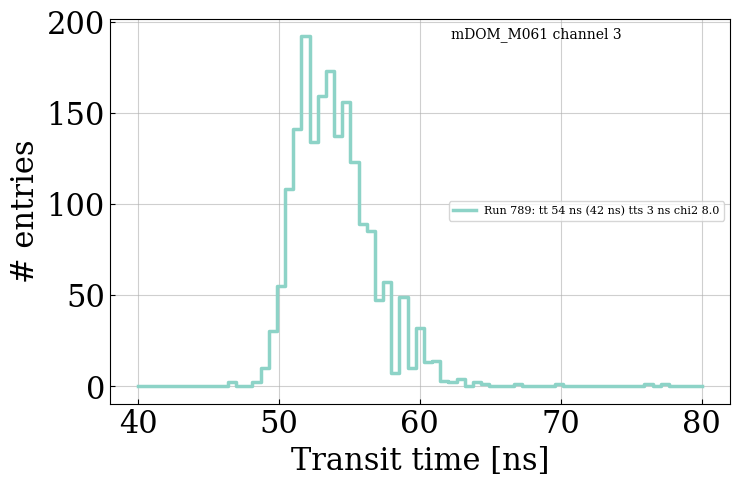

In [ ]:
for imdom_pmt_run in tt_less_23[:1]:
    # print(imdom_pmt_run)
    mdom,channel_run = imdom_pmt_run.split("_channel_")
    channel,run = channel_run.split("_")
    print(f"mdom {mdom} channel {channel} run {run}")
    plot_single_transit_time_histogram_include_run(mdom, int(channel), mdom_tt_dir, plotFolder,fit_line=False,fit_xlim=[-30,100],include_runs=[int(run)])


In [ ]:
# transit_times_single_per_pmt_msu = extract_json_site(transit_times_single_gaussian_file,site_str="_M",obj_key="mu",filter_non_zero=False)
# transit_times_single_per_pmt_desy = extract_json_site(transit_times_single_gaussian_file,site_str="_D",obj_key="mu",filter_non_zero=False)
# transit_times_spread_single_per_pmt_msu = extract_json_site(transit_times_single_gaussian_file,site_str="_M",obj_key="sigma",filter_non_zero=False)
# transit_times_spread_single_per_pmt_desy = extract_json_site(transit_times_single_gaussian_file,site_str="_D",obj_key="sigma",filter_non_zero=False)
# #

In [ ]:
#####################################
#############plot histogram##########
plot_transit_time_histogram(transit_times_single_per_pmt_msu, transit_times_single_per_pmt_desy,plotFolder+"/transit_time_gaussian_refit_histogram_final_corrected",bins=np.linspace(20,40,41),xlim=[20,40])
plot_transit_time_histogram(transit_times_single_per_pmt_msu, transit_times_single_per_pmt_desy,plotFolder+"/transit_time_gaussian_refit_histogram_final_corrected_components",bins=np.linspace(20,40,41),xlim=[20,40],no_component=None)

plot_transit_time_spread_histogram(transit_times_spread_single_per_pmt_msu,transit_times_spread_single_per_pmt_desy,plotFolder+"/transit_time_spread_single_gaussian_histogram_final",bins=np.linspace(0,8,33),xlim=[0,8],no_component=None)
# #######################################
# ###########plot residual###############
# rse_msu = extract_json_site(transit_times_single_gaussian_file, site_str="_M", obj_key="RSS", filter_non_zero=False)
# rse_desy = extract_json_site(transit_times_single_gaussian_file, site_str="_D", obj_key="RSS", filter_non_zero=False)
# # plot_rse_histogram(rse_msu, rse_desy, plotFolder+"/rse_histogram_final",bins=np.linspace(0,20,41),xlim=[0,20])
# print(f"plotting rse histogam")
# plot_rse_histogram(rse_msu, rse_desy, plotFolder+"/rse_gaussian_histogram_final",bins=np.linspace(-10**4,0.4*10**7,500),xlim=[-10**4,0.5*10**7],no_component=True)
# plot_rse_histogram(rse_msu, rse_desy, plotFolder+"/rse_gaussian_histogram_final_components",bins=np.linspace(-10**4,0.4*10**7,500),xlim=[-10**4,0.05*10**7],no_component=None)
